In [1]:
from scipy.interpolate import griddata
import numpy as np
import xarray as xr
from xcube.core.store import new_data_store
from xcube_resampling import rectify_dataset, affine_transform_dataset
from xcube_resampling.gridmapping import GridMapping
from dask.distributed import Client, LocalCluster
import matplotlib.pyplot as plt

xr.set_options(display_expand_attrs=False)

In [2]:
cluster = LocalCluster(
    n_workers=1,
    threads_per_worker=1,
    memory_limit="25GB",
    dashboard_address="8787",
)
client = Client(cluster)
client.dashboard_link

2026-01-19 15:35:22,777 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:8787', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/home/konstantin/micromamba/envs/xarray-eopf/lib/python3.13/site-packages/tornado/websocket.py", line 938, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
  File "/home/konstantin/micromamba/envs/xarray-eopf/lib/python3.13/site-packages/tornado/web.py", line 3301, in wrapper
    return method(self, *args, **kwargs)
  File "/home/konstantin/micromamba/envs/xarray-eopf/lib/python3.13/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.protocol.exceptions.ProtocolError: Token is expired. Configure the app with a larger value for --

'http://127.0.0.1:8787/status'

In [3]:
path = (
    "data/S1A_IW_GRDH_1SDV_20251209T165439_20251209T165508_062241_07CAD4_3B2A.zarr"
)

In [4]:
%%time
dt = xr.open_datatree(path, engine="zarr", chunks={})

CPU times: user 109 ms, sys: 7.05 ms, total: 116 ms
Wall time: 115 ms


In [5]:
%%time
group_VH = [x for x in dt.children if "VH" in x][0]
grd = dt[group_VH].measurements.to_dataset().rename({"grd": "vh"})
group_VV = [x for x in dt.children if "VV" in x][0]
grd["vv"] = dt[group_VV].measurements.to_dataset().grd
grd = grd.assign_coords(azimuth_time=(grd.azimuth_time - grd.azimuth_time[0]) / np.timedelta64(1, "s"))
grd = grd.assign_coords(ground_range=grd.ground_range / grd.sizes["ground_range"])
grd = grd.drop_vars(["line", "pixel"])
grd

CPU times: user 287 ms, sys: 7.12 ms, total: 295 ms
Wall time: 812 ms


<xarray.Dataset> Size: 2GB
Dimensions:       (azimuth_time: 19369, ground_range: 26361)
Coordinates:
  * azimuth_time  (azimuth_time) float64 155kB 0.0 0.001499 ... 29.04 29.04
  * ground_range  (ground_range) float64 211kB 0.0 0.0003793 ... 9.999 10.0
Data variables:
    vh            (azimuth_time, ground_range) uint16 1GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>
    vv            (azimuth_time, ground_range) uint16 1GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>

In [6]:
%%time
gm = GridMapping.from_coords(
    grd.ground_range,
    grd.azimuth_time,
    "EPSG:3857",
    tile_size=(grd.vv.data.chunksize[1], grd.vv.data.chunksize[0]),
)
gm

CPU times: user 30.8 ms, sys: 2.2 ms, total: 33 ms
Wall time: 49.5 ms


class: **Coords1DGridMapping**
* is_regular: True
* is_j_axis_up: True
* is_lon_360: _unknown_
* crs: EPSG:3857
* xy_res: (0.000379348, 0.00149938)
* xy_bbox: (-0.0001897, -0.0007497, 9.9998103, 29.0408157)
* ij_bbox: (0, 0, 26361, 19369)
* xy_dim_names: ('ground_range', 'azimuth_time')
* xy_var_names: ('ground_range', 'azimuth_time')
* size: (26361, 19369)
* tile_size: (4096, 2048)

In [7]:
%%time
gcps = dt[group_VH].conditions.gcp.to_dataset()
gcps = gcps[["latitude", "longitude"]]
gcps = gcps.assign_coords(azimuth_time=(gcps.azimuth_time - gcps.azimuth_time[0]) / np.timedelta64(1, "s"))
gcps = gcps.assign_coords(ground_range=gcps.ground_range / grd.sizes["ground_range"])
gcps

CPU times: user 42.2 ms, sys: 3.01 ms, total: 45.2 ms
Wall time: 76.2 ms


<xarray.Dataset> Size: 4kB
Dimensions:       (azimuth_time: 11, ground_range: 21)
Coordinates:
  * azimuth_time  (azimuth_time) float64 88B 0.0 3.0 6.001 ... 24.0 27.0 29.04
  * ground_range  (ground_range) float64 168B 0.0 0.5 1.0 1.5 ... 9.0 9.5 10.0
    line          (azimuth_time) uint32 44B dask.array<chunksize=(11,), meta=np.ndarray>
    pixel         (ground_range) uint32 84B dask.array<chunksize=(21,), meta=np.ndarray>
Data variables:
    latitude      (azimuth_time, ground_range) float64 2kB dask.array<chunksize=(11, 21), meta=np.ndarray>
    longitude     (azimuth_time, ground_range) float64 2kB dask.array<chunksize=(11, 21), meta=np.ndarray>

In [8]:
%%time
dummy_ds = gcps.copy()
dummy_ds = dummy_ds.assign_coords(
    dict(
        azimuth_time=np.linspace(
            gcps.azimuth_time[0].item(),
            gcps.azimuth_time[-1].item(),
            gcps.sizes["azimuth_time"],
        ),
        ground_range=np.linspace(
            gcps.ground_range[0].item(),
            gcps.ground_range[-1].item(),
            gcps.sizes["ground_range"],
        ),
    )
)
gcps = gcps.interp_like(dummy_ds)
gcps_gm = GridMapping.from_coords(gcps.ground_range, gcps.azimuth_time, "EPSG:3857")
gcps_gm

CPU times: user 208 ms, sys: 13.3 ms, total: 222 ms
Wall time: 431 ms


class: **Coords1DGridMapping**
* is_regular: True
* is_j_axis_up: True
* is_lon_360: _unknown_
* crs: EPSG:3857
* xy_res: (0.499981, 2.90401)
* xy_bbox: (-0.2499905, -1.452005, 10.2496112, 30.492071)
* ij_bbox: (0, 0, 21, 11)
* xy_dim_names: ('ground_range', 'azimuth_time')
* xy_var_names: ('ground_range', 'azimuth_time')
* size: (21, 11)
* tile_size: (21, 11)

In [9]:
%%time
gcps_interp = affine_transform_dataset(
    gcps,
    target_gm=gm,
    source_gm=gcps_gm,
    interp_methods=1,
)
gcps_interp

CPU times: user 45.7 ms, sys: 1.06 ms, total: 46.8 ms
Wall time: 44.7 ms


<xarray.Dataset> Size: 8GB
Dimensions:       (azimuth_time: 19369, ground_range: 26361)
Coordinates:
  * azimuth_time  (azimuth_time) float64 155kB 0.0 0.001499 ... 29.04 29.04
  * ground_range  (ground_range) float64 211kB 0.0 0.0003793 ... 9.999 10.0
    spatial_ref   int64 8B 0
Data variables:
    latitude      (azimuth_time, ground_range) float64 4GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>
    longitude     (azimuth_time, ground_range) float64 4GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>

In [10]:
%%time
grd = grd.assign_coords(dict(
    latitude=gcps_interp.latitude, 
    longitude=gcps_interp.longitude, 
))
grd

CPU times: user 1.71 ms, sys: 51 μs, total: 1.76 ms
Wall time: 1.38 ms


<xarray.Dataset> Size: 10GB
Dimensions:       (azimuth_time: 19369, ground_range: 26361)
Coordinates:
  * azimuth_time  (azimuth_time) float64 155kB 0.0 0.001499 ... 29.04 29.04
  * ground_range  (ground_range) float64 211kB 0.0 0.0003793 ... 9.999 10.0
    spatial_ref   int64 8B 0
    latitude      (azimuth_time, ground_range) float64 4GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>
    longitude     (azimuth_time, ground_range) float64 4GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>
Data variables:
    vh            (azimuth_time, ground_range) uint16 1GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>
    vv            (azimuth_time, ground_range) uint16 1GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>

In [11]:
%%time
grd_sub = grd.isel(
    azimuth_time=slice(0, 2048),
    ground_range=slice(0, 4096),
)
grd_sub

CPU times: user 1.41 ms, sys: 29 μs, total: 1.44 ms
Wall time: 1.44 ms


<xarray.Dataset> Size: 168MB
Dimensions:       (azimuth_time: 2048, ground_range: 4096)
Coordinates:
  * azimuth_time  (azimuth_time) float64 16kB 0.0 0.001499 ... 3.068 3.069
  * ground_range  (ground_range) float64 33kB 0.0 0.0003793 ... 1.553 1.553
    spatial_ref   int64 8B 0
    latitude      (azimuth_time, ground_range) float64 67MB dask.array<chunksize=(2048, 4096), meta=np.ndarray>
    longitude     (azimuth_time, ground_range) float64 67MB dask.array<chunksize=(2048, 4096), meta=np.ndarray>
Data variables:
    vh            (azimuth_time, ground_range) uint16 17MB dask.array<chunksize=(2048, 4096), meta=np.ndarray>
    vv            (azimuth_time, ground_range) uint16 17MB dask.array<chunksize=(2048, 4096), meta=np.ndarray>

In [13]:
%%time
source_gm = GridMapping.from_dataset(grd_sub)

CPU times: user 111 ms, sys: 10.4 ms, total: 121 ms
Wall time: 695 ms


In [14]:
%%time
target_gm = source_gm.to_regular()

CPU times: user 1.16 ms, sys: 15 μs, total: 1.18 ms
Wall time: 818 μs


In [15]:
%%time
grid_x_regular, grid_y_regular = np.meshgrid(target_gm.x_coords.values, target_gm.y_coords.values)
grid_x_regular

CPU times: user 30.7 ms, sys: 37.8 ms, total: 68.5 ms
Wall time: 69.5 ms


array([[15.7382395 , 15.73834169, 15.73844387, ..., 16.19900063,
        16.19910281, 16.199205  ],
       [15.7382395 , 15.73834169, 15.73844387, ..., 16.19900063,
        16.19910281, 16.199205  ],
       [15.7382395 , 15.73834169, 15.73844387, ..., 16.19900063,
        16.19910281, 16.199205  ],
       ...,
       [15.7382395 , 15.73834169, 15.73844387, ..., 16.19900063,
        16.19910281, 16.199205  ],
       [15.7382395 , 15.73834169, 15.73844387, ..., 16.19900063,
        16.19910281, 16.199205  ],
       [15.7382395 , 15.73834169, 15.73844387, ..., 16.19900063,
        16.19910281, 16.199205  ]], shape=(2816, 4512))

In [16]:
%%time
vh_interp = griddata(
    (
        grd_sub.longitude.values.flatten(),
        grd_sub.latitude.values.flatten()
    ),
    grd_sub.vh.values.flatten(),
    (grid_x_regular, grid_y_regular),
    method="nearest",
)

CPU times: user 44.5 s, sys: 507 ms, total: 45 s
Wall time: 44.1 s


CPU times: user 52.8 ms, sys: 25 ms, total: 77.8 ms
Wall time: 107 ms


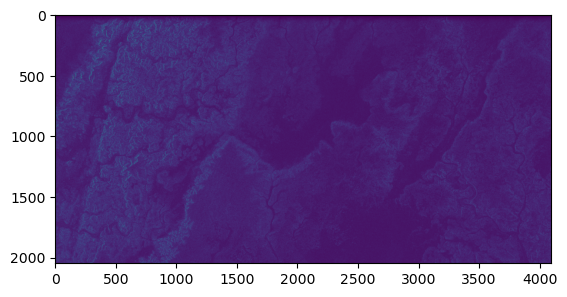

In [17]:
%%time
plt.imshow(grd_sub.vh.values)

CPU times: user 46.5 ms, sys: 8.98 ms, total: 55.4 ms
Wall time: 49.3 ms


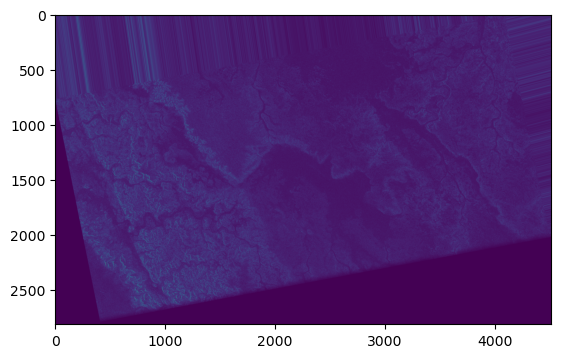

In [18]:
%%time
plt.imshow(vh_interp)